# PCA

## Example 1: COVID data

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("../05-data_cleaning/data/covidtotals.csv")

cols = [
    "pop_density", "median_age", "gdp_per_capita",
    "hosp_beds", "life_expectancy", "hum_dev_ind"
]

df_clean = df[cols].dropna()

### Standardize Data
PCA is scale sensitive

In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

### Run PCA

In [84]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [85]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)
print("Cumulative:", np.cumsum(explained_variance))

[0.62711164 0.17751553 0.10886876 0.05684184 0.01951709 0.01014514]
Cumulative: [0.62711164 0.80462717 0.91349593 0.97033777 0.98985486 1.        ]


Text(0, 0.5, 'Cumulative Explained Variance')

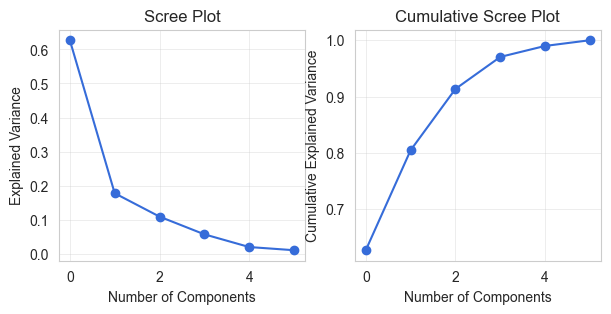

In [91]:

sns.set_style('whitegrid')
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

axes.flat[0].plot(explained_variance, marker='o')
axes.flat[0].set_title("Scree Plot")
axes.flat[1].plot(np.cumsum(explained_variance), marker='o')
axes.flat[1].set_title("Cumulative Scree Plot")

for ax in axes.flat:
    ax.set_xlabel("Number of Components")

axes.flat[0].set_ylabel("Explained Variance")
axes.flat[1].set_ylabel("Cumulative Explained Variance")



### Loadings

Loadings tell us what each principal component represents. We often keep components that explain ~80-90% variance. Therefore, we can keep the first two or three.


In [20]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(cols))],
    index=cols
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
pop_density,0.118324,0.867297,0.463301,-0.130315,-0.018110,0.042859
median_age,0.482686,-0.126746,0.086743,-0.269334,0.797340,-0.187437
gdp_per_capita,0.406263,0.277045,-0.391460,0.755992,0.055067,-0.174355
hosp_beds,0.339512,-0.390484,0.738318,0.342461,-0.251415,-0.081555
life_expectancy,0.474220,0.006813,-0.237210,-0.453555,-0.527351,-0.484756
hum_dev_ind,0.497807,-0.049524,-0.152331,-0.126340,-0.139923,0.831259


Interpretation:
- PC1 high on Human Development Index (HDI), median age, and life expectancy
- PC2 high on population density
- PC3 high on hospital beds available.

### Use reduced data
Now we have reduced variables from six to two

In [29]:
X_reduced = X_pca[:, :2]

### Run regression after reducing dimensions
to avoid multicolinearity

In [33]:
import statsmodels.api as sm

X = sm.add_constant(X_reduced)
y = df["total_cases"].loc[df_clean.index]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            total_cases   R-squared:                       0.087
Model:                            OLS   Adj. R-squared:                  0.075
Method:                 Least Squares   F-statistic:                     7.403
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           0.000849
Time:                        14:35:29   Log-Likelihood:                -2829.5
No. Observations:                 159   AIC:                             5665.
Df Residuals:                     156   BIC:                             5674.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.828e+06   1.04e+06      4.656      0.0

## Example 2: NLS97 data

RQ: what factors predict income?

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['wageincome', 'highestgradecompleted', 'birthyear', 'gender', 'gpaoverall', 'gpaenglish',
       'gpamath', 'gpascience', 'maritalstatus']

df = pd.read_csv("../05-data_cleaning/data/nls97.csv")

# clean data
num_vars = ['wageincome', 'highestgradecompleted', 'birthyear', 'gpaoverall', 'gpaenglish',
       'gpamath', 'gpascience']
cat_vars = ['gender', 'maritalstatus']

for col in num_vars:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df_clean = df[cols].dropna()

df_clean['is_women'] = (df_clean['gender'] == "Female").astype(int)
df_clean['is_married'] = (df_clean['maritalstatus'] == "Married").astype(int)
df_clean['age'] = 2020-df_clean['birthyear']

df_clean.head()

,wageincome,highestgradecompleted,birthyear,gender,gpaoverall,gpaenglish,gpamath,gpascience,maritalstatus,is_women,is_married,age
0,12500.0,13.0,1980,Female,306.0,350.0,280.0,315.0,Married,1,1,40
4,30000.0,13.0,1980,Male,291.0,283.0,285.0,240.0,Married,0,1,40
5,39000.0,12.0,1981,Male,246.0,200.0,307.0,138.0,Married,0,1,39
7,36000.0,13.0,1980,Male,251.0,236.0,282.0,198.0,Never-married,0,0,40
11,50000.0,20.0,1980,Female,363.0,357.0,343.0,360.0,Married,1,1,40


In [93]:
print(df_clean.describe())

print(df_clean[[
    "wageincome", "highestgradecompleted", "age",
    "gpaoverall", "gpamath"
]].corr())

          wageincome  highestgradecompleted    birthyear   gpaoverall  \
count    3413.000000            3413.000000  3413.000000  3413.000000   
mean    52740.093759              14.988866  1981.949018   291.661588   
std     41892.814305               3.857043     1.415780    56.406939   
min         0.000000               6.000000  1980.000000    42.000000   
25%     27000.000000              12.000000  1981.000000   254.000000   
50%     44000.000000              15.000000  1982.000000   295.000000   
75%     65000.000000              17.000000  1983.000000   334.000000   
max    235884.000000              95.000000  1984.000000   411.000000   

        gpaenglish      gpamath   gpascience     is_women   is_married  \
count  3413.000000  3413.000000  3413.000000  3413.000000  3413.000000   
mean    279.536771   267.645766   271.376502     0.495166     0.521242   
std      71.176149    71.781763    74.720741     0.500050     0.499622   
min       0.000000     0.000000     0.000000  

In [94]:
df_clean = df_clean[(df_clean['highestgradecompleted']<40) & (df_clean['wageincome']<200000)].copy()

### Select numeric variables for PCA
We usually expclude the outcome variable from PCA

In [95]:
features = [
    'highestgradecompleted', 'age',
    'gpaoverall', 'gpaenglish', 'gpamath', 'gpascience',
    'is_women', 'is_married'
]

X = df_clean[features]

### Standardize data

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Run PCA

In [97]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

### Explained variance

In [98]:
explained = pca.explained_variance_ratio_

print("Explained variance:", explained)
print("Cumulative:", np.cumsum(explained))

Explained variance: [0.43965391 0.13703187 0.12257401 0.10902639 0.08846116 0.05098709
 0.0395818  0.01268376]
Cumulative: [0.43965391 0.57668579 0.69925979 0.80828618 0.89674735 0.94773444
 0.98731624 1.        ]


### Scree plot

Text(0, 0.5, 'Cumulative Explained Variance')

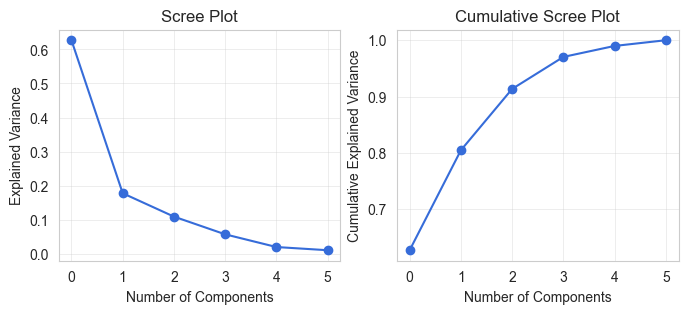

In [100]:

sns.set_style('whitegrid')
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 3))

axes.flat[0].plot(explained_variance, marker='o')
axes.flat[0].set_title("Scree Plot")
axes.flat[1].plot(np.cumsum(explained_variance), marker='o')
axes.flat[1].set_title("Cumulative Scree Plot")

for ax in axes.flat:
    ax.set_xlabel("Number of Components")

axes.flat[0].set_ylabel("Explained Variance")
axes.flat[1].set_ylabel("Cumulative Explained Variance")




### Loadings

In [59]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(features))],
    index=features
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
highestgradecompleted,0.321088,0.102201,0.098009,0.240398,0.884096,0.132009,-0.133219,-0.047549
age,-0.039502,0.725276,0.257660,-0.631854,0.078545,-0.007089,0.020393,0.012319
gpaoverall,0.507263,-0.032152,-0.070162,-0.084987,-0.073942,-0.070139,0.133880,0.837374
gpaenglish,0.470678,-0.044088,0.035682,-0.050997,-0.025517,-0.329967,0.691837,-0.429508
gpamath,0.425899,-0.045451,-0.149070,-0.183413,-0.226022,0.806897,-0.066382,-0.232610
gpascience,0.449901,-0.031250,-0.098088,-0.145225,-0.157192,-0.459897,-0.687364,-0.239203
is_women,0.142399,-0.061307,0.914038,0.259901,-0.241342,0.078296,-0.091498,0.014223
is_married,0.111403,0.673611,-0.224726,0.640989,-0.268413,0.002895,0.005232,-0.019691


### Interpret results

- PC1: high loadings on GPA scores and highest grade completed (overall academic performance)
- PC2: age and marital status (demographic and/or life stage factor)
- PC3: gender

### Visualize PCA Space

0 1
0 2
1 2


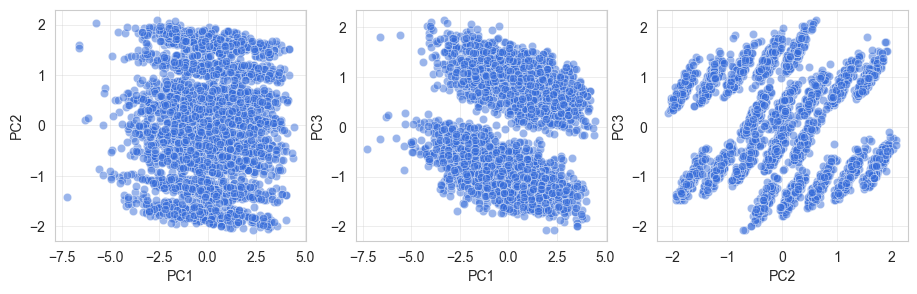

In [67]:
from itertools import combinations
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(11, 3))

for ax, (pcx, pcy) in zip(axes.flat, combinations((0, 1, 2), 2)):
    print(pcx, pcy)
    sns.scatterplot(x=X_pca[:, pcx], y=X_pca[:, pcy], alpha=0.5, ax=ax)
    # plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
    ax.set_xlabel(f"PC{pcx+1}")
    ax.set_ylabel(f"PC{pcy+1}")

# plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.title("PCA Projection")
# plt.show()

### Reduce dimensions
Eight dimensions reduced to three

In [77]:
X_reduced = X_pca[:, :3]

### post-PCA regression

PCA solves multicollinearity and high dimensionality, but loses interpretability (r-squared likely reduced).

In [78]:
import statsmodels.api as sm

y = df_clean["wageincome"]

X_reg = sm.add_constant(X_reduced)

model = sm.OLS(y, X_reg).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             wageincome   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     191.2
Date:                Sun, 05 Apr 2026   Prob (F-statistic):          2.40e-114
Time:                        15:22:21   Log-Likelihood:                -38536.
No. Observations:                3317   AIC:                         7.708e+04
Df Residuals:                    3313   BIC:                         7.711e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.764e+04    466.909    102.039      0.0

In [74]:
# compare to previous regressions without PCA

y = df_clean["wageincome"]

X_reg = sm.add_constant(X[features])

model = sm.OLS(y, X_reg).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             wageincome   R-squared:                       0.204
Model:                            OLS   Adj. R-squared:                  0.202
Method:                 Least Squares   F-statistic:                     105.9
Date:                Sun, 05 Apr 2026   Prob (F-statistic):          9.80e-158
Time:                        15:19:58   Log-Likelihood:                -38423.
No. Observations:                3317   AIC:                         7.686e+04
Df Residuals:                    3308   BIC:                         7.692e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                 -3.768e+